In [1]:
import sys, os
sys.path.insert(0, '../../utils')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from utils import load_neurons_table, load_synapses_position_transformed
from connectome_types import CONNECTOME_SYN_TABLE_PATH, CONNECTOME_PRE_SYN_TABLE_PATH, SPINE_TABLE_OUTGOING
from neuron_custom_features import calc_spines_features
from spines_utils import filter_valid_neuron_w_spines
from plot_utils import ex_color
from spine_pref_utils import get_crossing_distances_by_neuron

In [3]:
neurons_df = load_neurons_table()
syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_SYN_TABLE_PATH)
df, syn_with_tags = calc_spines_features(neurons_df, syn_df)
df, filtered_syn_mat, filtered_bin_mat, filtered_mapping, filtered_reverse_mapping, ex_neurons, inh_neurons = filter_valid_neuron_w_spines(df)

spine_df_outgoing = pd.read_csv(SPINE_TABLE_OUTGOING)
outgoing_syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_PRE_SYN_TABLE_PATH)
outgoing_syn_with_tags = outgoing_syn_df[outgoing_syn_df.id_.isin(spine_df_outgoing.target_id)].copy()
outgoing_syn_with_tags['tag'] = outgoing_syn_with_tags.id_.map(spine_df_outgoing.set_index('target_id').tag)

ex_outgoing_syn_with_tags = outgoing_syn_with_tags[outgoing_syn_with_tags.pre_clf_type == 'E']

connectome neurons table:  1351
valid neurons w position: 1351
spine table incoming size (4567647, 4)
spine table outgoing size (819832, 4)
neurons: 1351
synapses with tags: 145356


100%|██████████| 1351/1351 [00:12<00:00, 104.90it/s]


Filtering neurons with valid spine data...
Remaining neurons after filtering: 1298
fixing networks
Filtering: Reducing matrix from 1351 to 1298 neurons.


In [4]:
crossing_distances = get_crossing_distances_by_neuron(
    ex_outgoing_syn_with_tags, max_distance=1200, num_pop_bins=160)
cross_dist_df = pd.DataFrame(list(crossing_distances.items()), columns=['pre_id', 'crossing_distance'])

merged_df = ex_neurons.merge(cross_dist_df, left_on='root_id', right_on='pre_id', how='left')
merged_df = merged_df.drop(columns=['pre_id'])
merged_df = merged_df.sort_values('cell_type')

ignore_cell_type = ['WM-P', 'Unsure E']
merged_df = merged_df[~merged_df['cell_type'].isin(ignore_cell_type)]
merged_df['cell_type'] = merged_df['cell_type'].cat.remove_unused_categories()

In [5]:
plt.rcParams['font.size'] = 13
plt.rcParams['font.family'] = 'Arial'

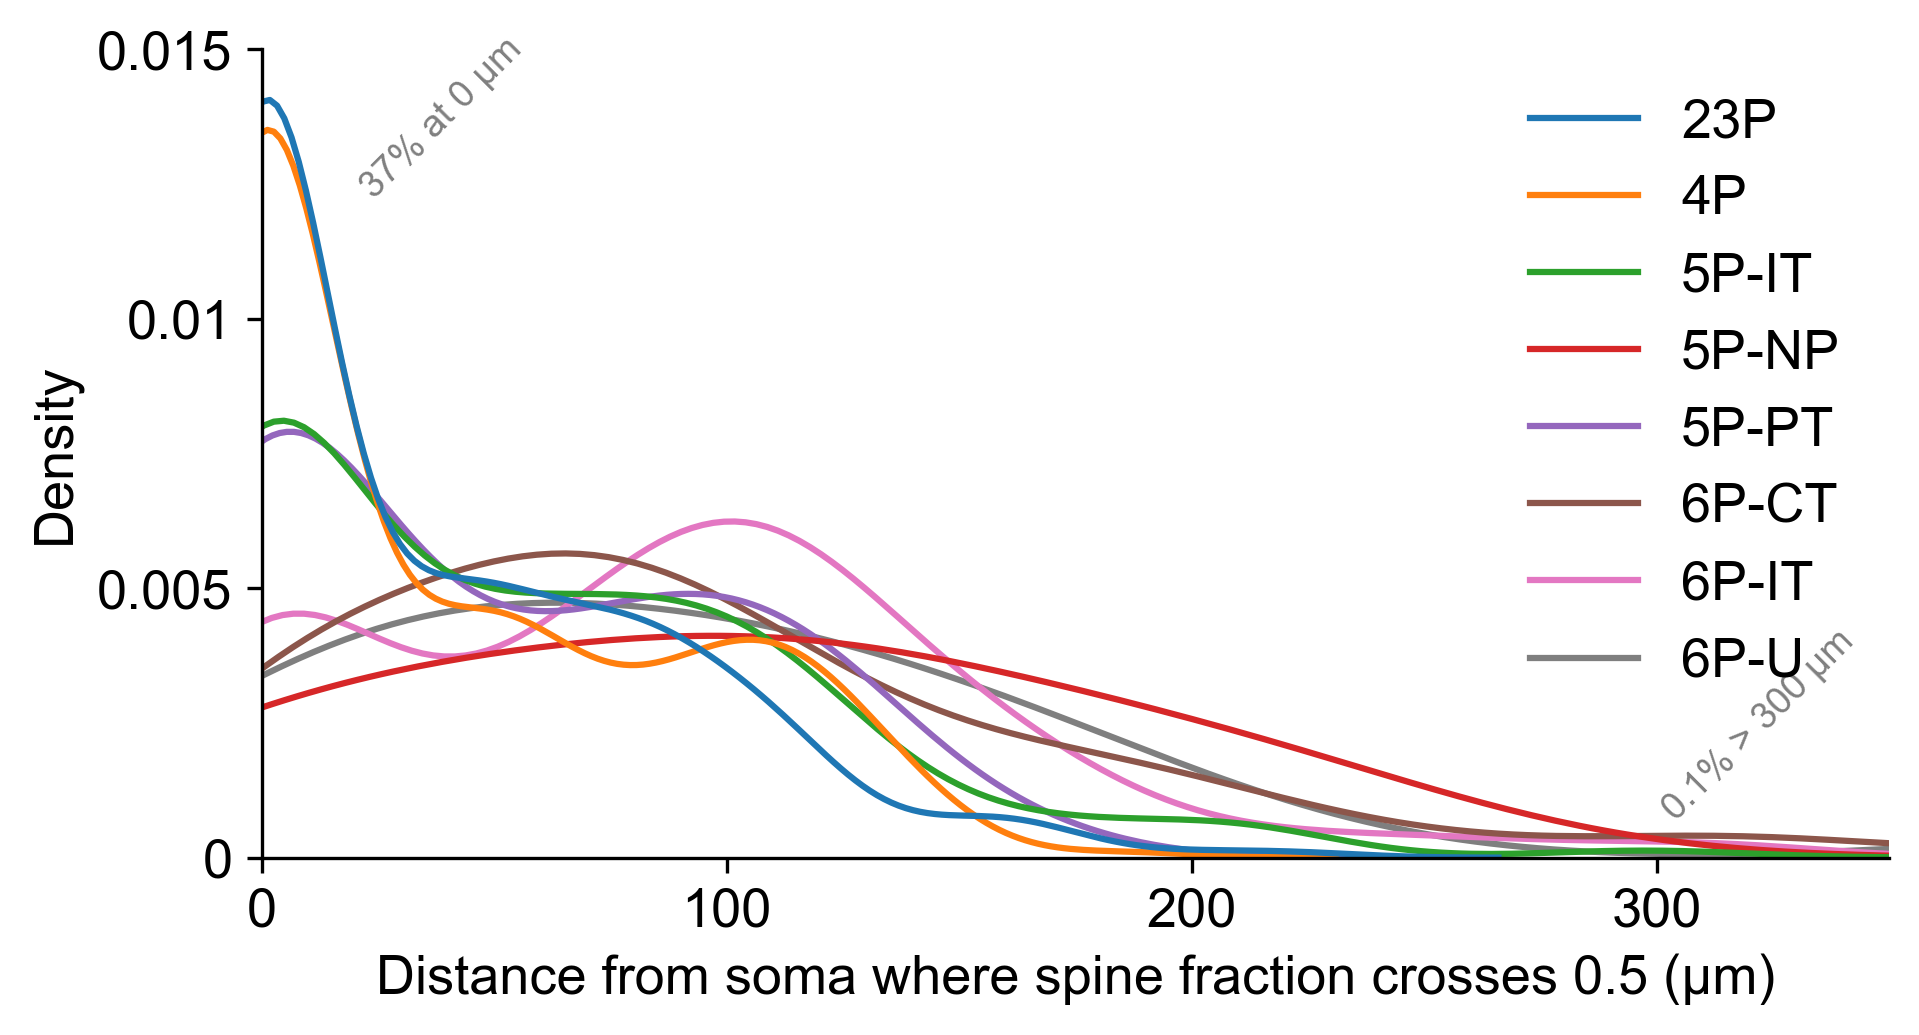

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5), dpi=300)

sns.kdeplot(data=merged_df, x='crossing_distance', hue='cell_type', ax=ax, fill=False,
            bw_adjust=1, common_norm=False)
ax.set_xlim(0, 350)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Distance from soma where spine fraction crosses 0.5 (\u03bcm)')
sns.move_legend(ax, loc='best', title=None, frameon=False)

# statistics
total_count = len(merged_df)
num_zeros = len(merged_df[merged_df['crossing_distance'] == 0])
num_infs = len(merged_df[np.isinf(merged_df['crossing_distance'])])
ax.text(20, 0.01225, f'{num_zeros/total_count*100:.0f}% at 0 \u03bcm', fontsize=9, rotation=45, color='gray')
ax.text(300, 0.0007, f'{num_infs/total_count*100:.1f}% > 300 \u03bcm', fontsize=9, rotation=45, color='gray')
ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))

ax.set_yticks(ax.get_yticks()[::2])
ax.set_xticks(ax.get_xticks()[::2])

plt.savefig('fig_s7.pdf', format='pdf', bbox_inches='tight')